PART A including PART C

In [1]:
import re
import time
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedGroupKFold,
    GridSearchCV, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [2]:
DATASET_ROOT = Path.cwd() / "data"

# folder name -> label.  Crack = 1 is the POSITIVE class.
CLASS_FOLDERS = {"NonCracks": 0, "Cracks": 1}
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

print("Dataset root:", DATASET_ROOT)

for folder in CLASS_FOLDERS:
    folder_path = DATASET_ROOT / folder
    n_images = sum(
        1 for p in folder_path.iterdir()
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    )
    print(f"{folder:10s} exists={folder_path.exists()}  images={n_images}")

Dataset root: d:\machine\Foml lab\202618002_Deeksha_DS605\202618002_LAB06\data
NonCracks  exists=True  images=200
Cracks     exists=True  images=200


In [3]:
records = []

for folder, label in CLASS_FOLDERS.items():
    for path in sorted((DATASET_ROOT / folder).iterdir()):
        if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS:
            records.append({
                "path": path,
                "image_name": path.name,
                "label": label,
                "class": folder
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
df.head()

Total images: 400


,path,image_name,label,class
0,d:\machine\Foml lab\202618002_Deeksha_DS605\20...,IMG_20180705_130729936 resized_448.jpg,0,NonCracks
1,d:\machine\Foml lab\202618002_Deeksha_DS605\20...,IMG_20180705_130731751 resized_448.jpg,0,NonCracks
2,d:\machine\Foml lab\202618002_Deeksha_DS605\20...,IMG_20180705_130732496 resized_448.jpg,0,NonCracks
3,d:\machine\Foml lab\202618002_Deeksha_DS605\20...,IMG_20180705_130732993 resized_448.jpg,0,NonCracks
4,d:\machine\Foml lab\202618002_Deeksha_DS605\20...,IMG_20180705_130733329 resized_448.jpg,0,NonCracks


class
NonCracks    200
Cracks       200
Name: count, dtype: int64

class
NonCracks    0.5
Cracks       0.5
Name: proportion, dtype: float64


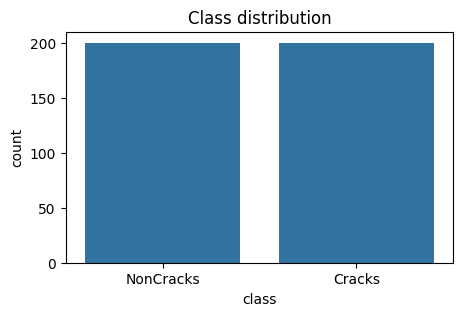

In [4]:
print(df["class"].value_counts())
print()
print(df["class"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="class")
plt.title("Class distribution")
plt.show()

In [5]:
# One crack sample and one non-crack sample (kept for the whole walkthrough)
crack_path = df[df["label"] == 1].iloc[0]["path"]
noncrack_path = df[df["label"] == 0].iloc[0]["path"]

sample_path = crack_path
sample_image = cv2.imread(str(sample_path))        

print("File    :", sample_path.name)
print("Shape   :", sample_image.shape)
print("Height  :", sample_image.shape[0])
print("Width   :", sample_image.shape[1])
print("Channels:", sample_image.shape[2])
print("Dtype   :", sample_image.dtype)

File    : IMG_20180513_164959951_HDR resized_448.jpg
Shape   : (448, 448, 3)
Height  : 448
Width   : 448
Channels: 3
Dtype   : uint8


In [6]:
shape_counts = {}
unreadable = []

for p in df["path"]:
    img = cv2.imread(str(p))
    if img is None:
        unreadable.append(p)
    else:
        shape_counts[img.shape] = shape_counts.get(img.shape, 0) + 1

print("Unique image shapes (shape -> count):")
for shape, count in shape_counts.items():
    print(" ", shape, "->", count)

print("\nUnreadable files:", len(unreadable))

Unique image shapes (shape -> count):
  (448, 448, 3) -> 400

Unreadable files: 0


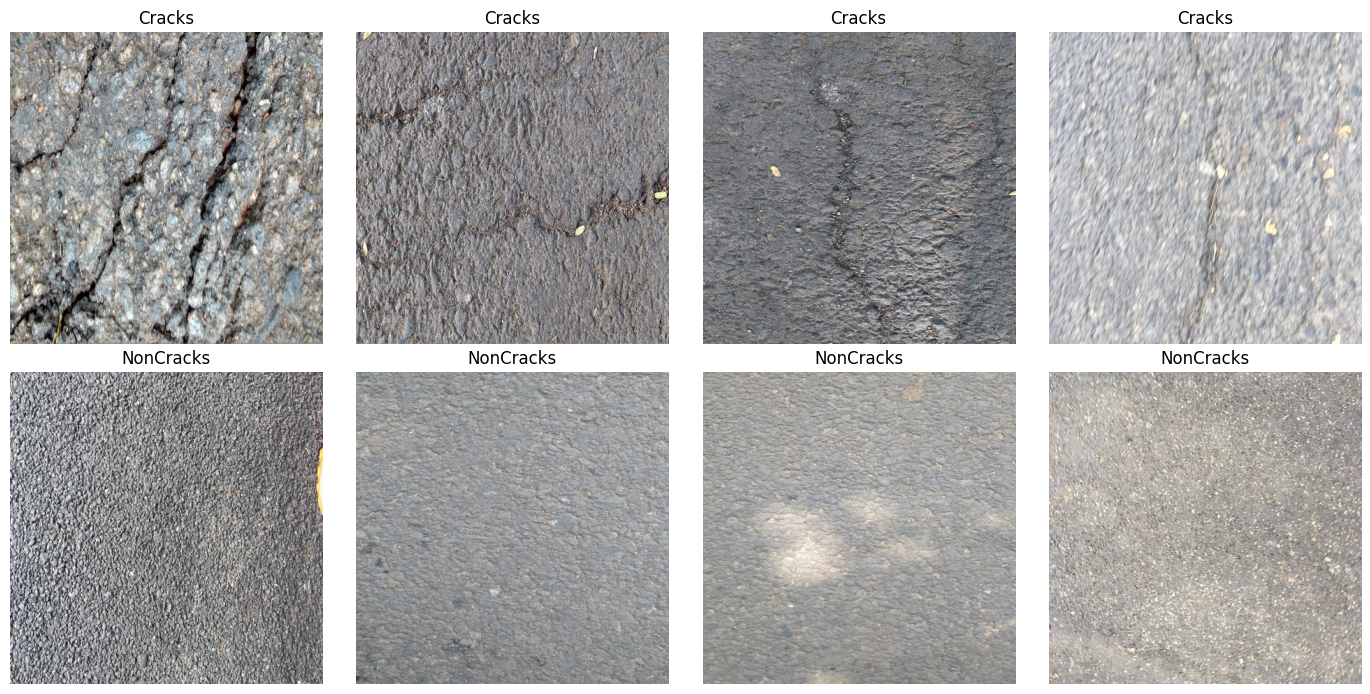

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, (class_name, label) in enumerate([("Cracks", 1), ("NonCracks", 0)]):
    samples = df[df["label"] == label].sample(4, random_state=RANDOM_STATE)

    for col, (_, r) in enumerate(samples.iterrows()):
        img = cv2.cvtColor(cv2.imread(str(r["path"])), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### Resize

Original shape: (448, 448, 3)
Resized shape : (256, 256, 3)


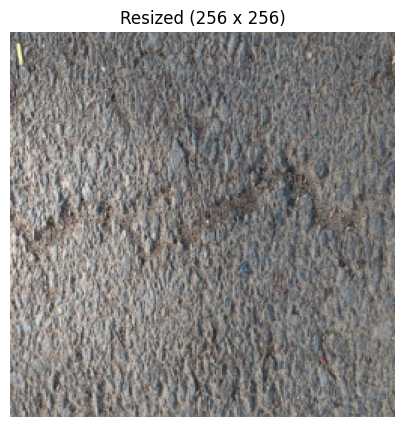

In [9]:
TARGET_SIZE = (256, 256)

resized_image = cv2.resize(sample_image, TARGET_SIZE, interpolation=cv2.INTER_AREA)

print("Original shape:", sample_image.shape)
print("Resized shape :", resized_image.shape)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Resized (256 x 256)")
plt.axis("off")
plt.show()

### Grayscale

Grayscale shape: (256, 256) | dtype: uint8


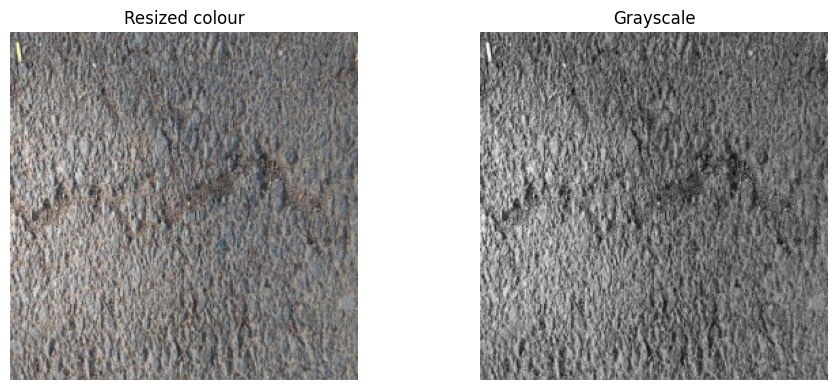

In [10]:
gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

print("Grayscale shape:", gray_image.shape, "| dtype:", gray_image.dtype)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)); axes[0].set_title("Resized colour")
axes[1].imshow(gray_image, cmap="gray");                      axes[1].set_title("Grayscale")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

### Gaussian smoothing

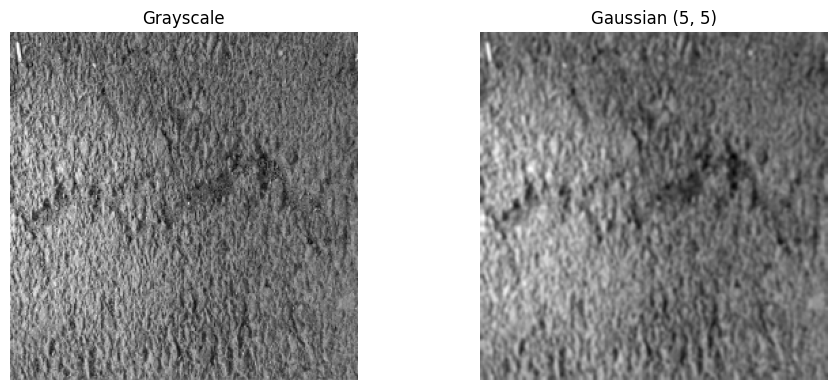

In [11]:
BLUR_KSIZE = (5, 5)

blurred_image = cv2.GaussianBlur(gray_image, BLUR_KSIZE, 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray_image, cmap="gray");    axes[0].set_title("Grayscale")
axes[1].imshow(blurred_image, cmap="gray"); axes[1].set_title(f"Gaussian {BLUR_KSIZE}")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

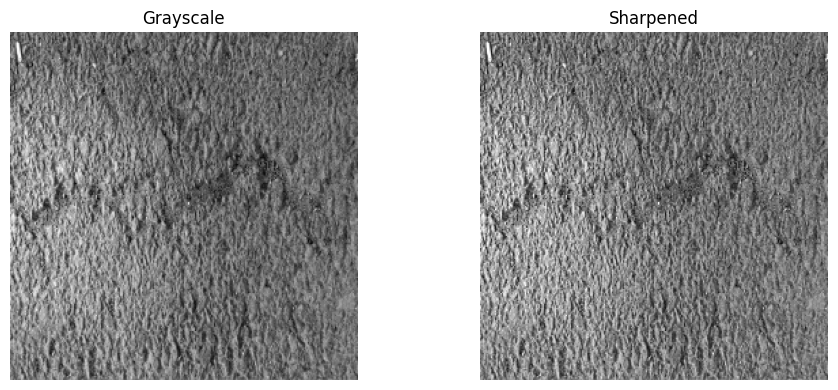

In [12]:
# sharpened = 1.5 * original - 0.5 * blurred  -> boosts fine detail
sharpened_image = cv2.addWeighted(gray_image, 1.5, blurred_image, -0.5, 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray_image, cmap="gray");      axes[0].set_title("Grayscale")
axes[1].imshow(sharpened_image, cmap="gray"); axes[1].set_title("Sharpened")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

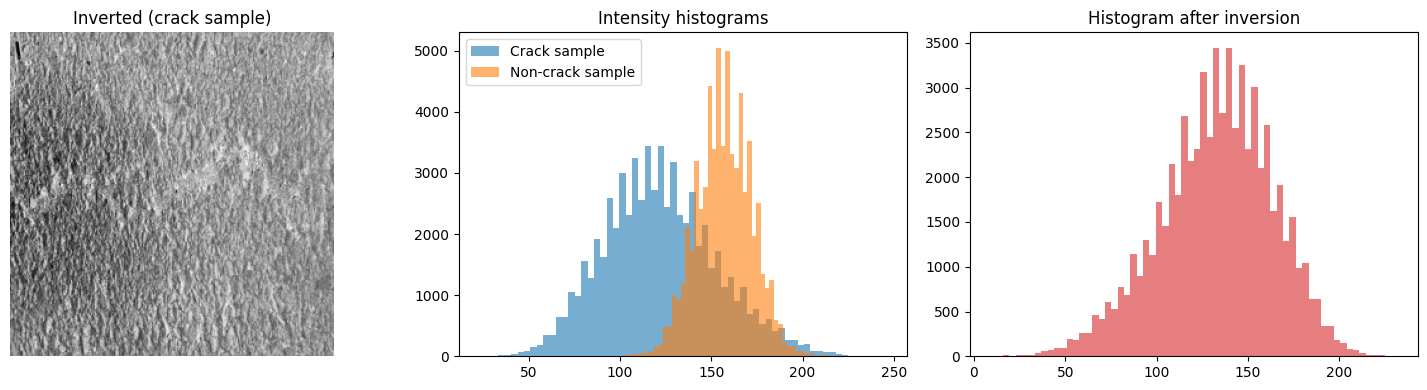

In [13]:
inverted_image = 255 - gray_image

noncrack_gray = cv2.cvtColor(
    cv2.resize(cv2.imread(str(noncrack_path)), TARGET_SIZE, interpolation=cv2.INTER_AREA),
    cv2.COLOR_BGR2GRAY
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(inverted_image, cmap="gray")
axes[0].set_title("Inverted (crack sample)")
axes[0].axis("off")

axes[1].hist(gray_image.ravel(), bins=64, alpha=0.6, label="Crack sample")
axes[1].hist(noncrack_gray.ravel(), bins=64, alpha=0.6, label="Non-crack sample")
axes[1].set_title("Intensity histograms")
axes[1].legend()

axes[2].hist(inverted_image.ravel(), bins=64, alpha=0.6, color="tab:red")
axes[2].set_title("Histogram after inversion")

plt.tight_layout(); plt.show()

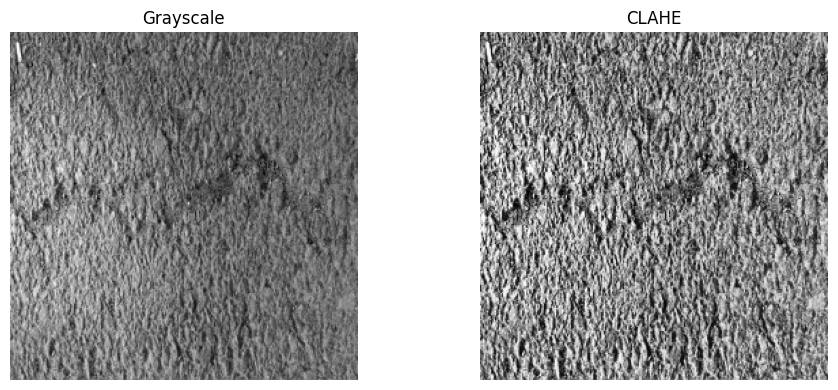

In [14]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_image = clahe.apply(gray_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray_image, cmap="gray");  axes[0].set_title("Grayscale")
axes[1].imshow(clahe_image, cmap="gray"); axes[1].set_title("CLAHE")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

cv2.Sobel == filter2D with Sobel kernel: True


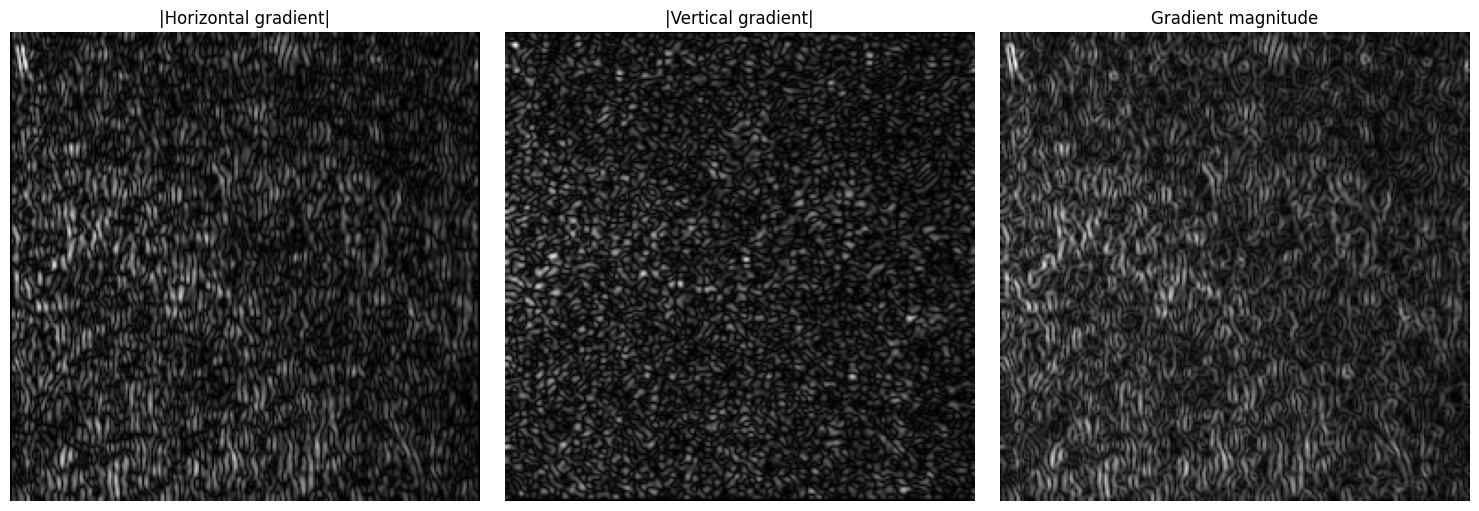

Mean gradient magnitude: 61.44762996003513
Std  gradient magnitude: 38.926220358846194


In [15]:
# 6.1 Horizontal gradient, 6.2 vertical gradient
sobel_x = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)

# 6.3 Gradient magnitude
grad_magnitude = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

# The same thing written as an explicit convolution kernel
kernel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=np.float64)
sobel_x_manual = cv2.filter2D(blurred_image.astype(np.float64), -1, kernel_x)
print("cv2.Sobel == filter2D with Sobel kernel:", np.allclose(sobel_x, sobel_x_manual))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(np.abs(sobel_x), cmap="gray");   axes[0].set_title("|Horizontal gradient|")
axes[1].imshow(np.abs(sobel_y), cmap="gray");   axes[1].set_title("|Vertical gradient|")
axes[2].imshow(grad_magnitude, cmap="gray");    axes[2].set_title("Gradient magnitude")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

print("Mean gradient magnitude:", grad_magnitude.mean())
print("Std  gradient magnitude:", grad_magnitude.std())

In [16]:
CANNY_METHOD = "adaptive"      # "normal" or "adaptive"
CANNY_SIGMA = 0.33


def get_canny_thresholds(image):
    if CANNY_METHOD == "normal":
        return 100, 200
    median = np.median(image)
    lower = int(max(0, (1.0 - CANNY_SIGMA) * median))
    upper = int(min(255, (1.0 + CANNY_SIGMA) * median))
    return lower, upper


lower, upper = get_canny_thresholds(blurred_image)
print("Canny method:", CANNY_METHOD, "| thresholds:", lower, upper)

Canny method: adaptive | thresholds: 79 158


### edge image

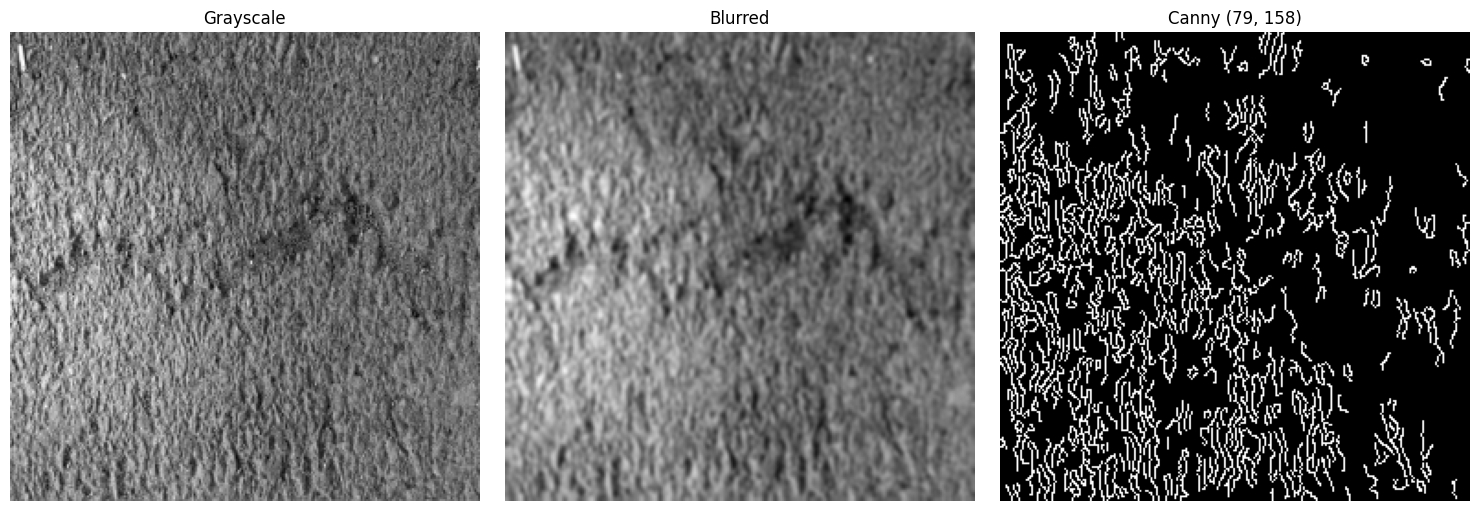

In [17]:
edges = cv2.Canny(blurred_image, lower, upper)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray_image, cmap="gray");    axes[0].set_title("Grayscale")
axes[1].imshow(blurred_image, cmap="gray"); axes[1].set_title("Blurred")
axes[2].imshow(edges, cmap="gray");         axes[2].set_title(f"Canny ({lower}, {upper})")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [18]:
edge_count = np.count_nonzero(edges)
edge_density = edge_count / edges.size

print("Edge count  :", edge_count)
print("Edge density:", edge_density)

Edge count  : 9559
Edge density: 0.1458587646484375


In [19]:
variants = {
    "Grayscale": gray_image,
    "Blurred": blurred_image,
    "Sharpened": cv2.GaussianBlur(sharpened_image, BLUR_KSIZE, 0),
    "Inverted": cv2.GaussianBlur(inverted_image, BLUR_KSIZE, 0),
    "CLAHE": cv2.GaussianBlur(clahe_image, BLUR_KSIZE, 0),
}

rows = []
for name, img in variants.items():
    lo, hi = get_canny_thresholds(img)
    e = cv2.Canny(img, lo, hi)
    rows.append({"variant": name, "lower": lo, "upper": hi,
                 "edge_count": np.count_nonzero(e),
                 "edge_density": np.count_nonzero(e) / e.size})

pd.DataFrame(rows)

,variant,lower,upper,edge_count,edge_density
0,Grayscale,80,159,23747,0.362350
1,Blurred,79,158,9559,0.145859
2,Sharpened,80,159,13523,0.206345
3,Inverted,91,180,6067,0.092575
4,CLAHE,89,176,20885,0.318680


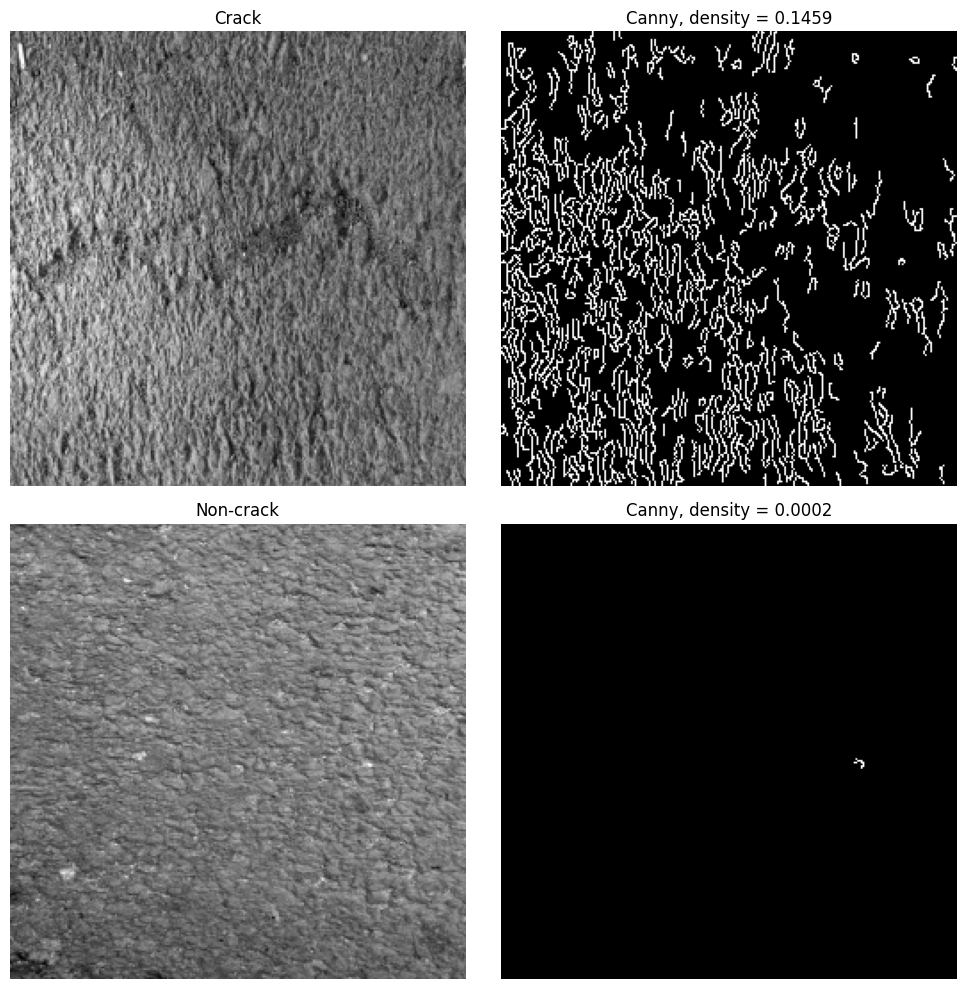

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, (title, p) in enumerate([("Crack", crack_path), ("Non-crack", noncrack_path)]):
    g = cv2.cvtColor(cv2.resize(cv2.imread(str(p)), TARGET_SIZE, interpolation=cv2.INTER_AREA),
                     cv2.COLOR_BGR2GRAY)
    b = cv2.GaussianBlur(g, BLUR_KSIZE, 0)
    lo, hi = get_canny_thresholds(b)
    e = cv2.Canny(b, lo, hi)

    axes[i, 0].imshow(g, cmap="gray")
    axes[i, 0].set_title(title)
    axes[i, 1].imshow(e, cmap="gray")
    axes[i, 1].set_title(f"Canny, density = {np.count_nonzero(e) / e.size:.4f}")
    axes[i, 0].axis("off"); axes[i, 1].axis("off")

plt.tight_layout(); plt.show()

### Hough Transform

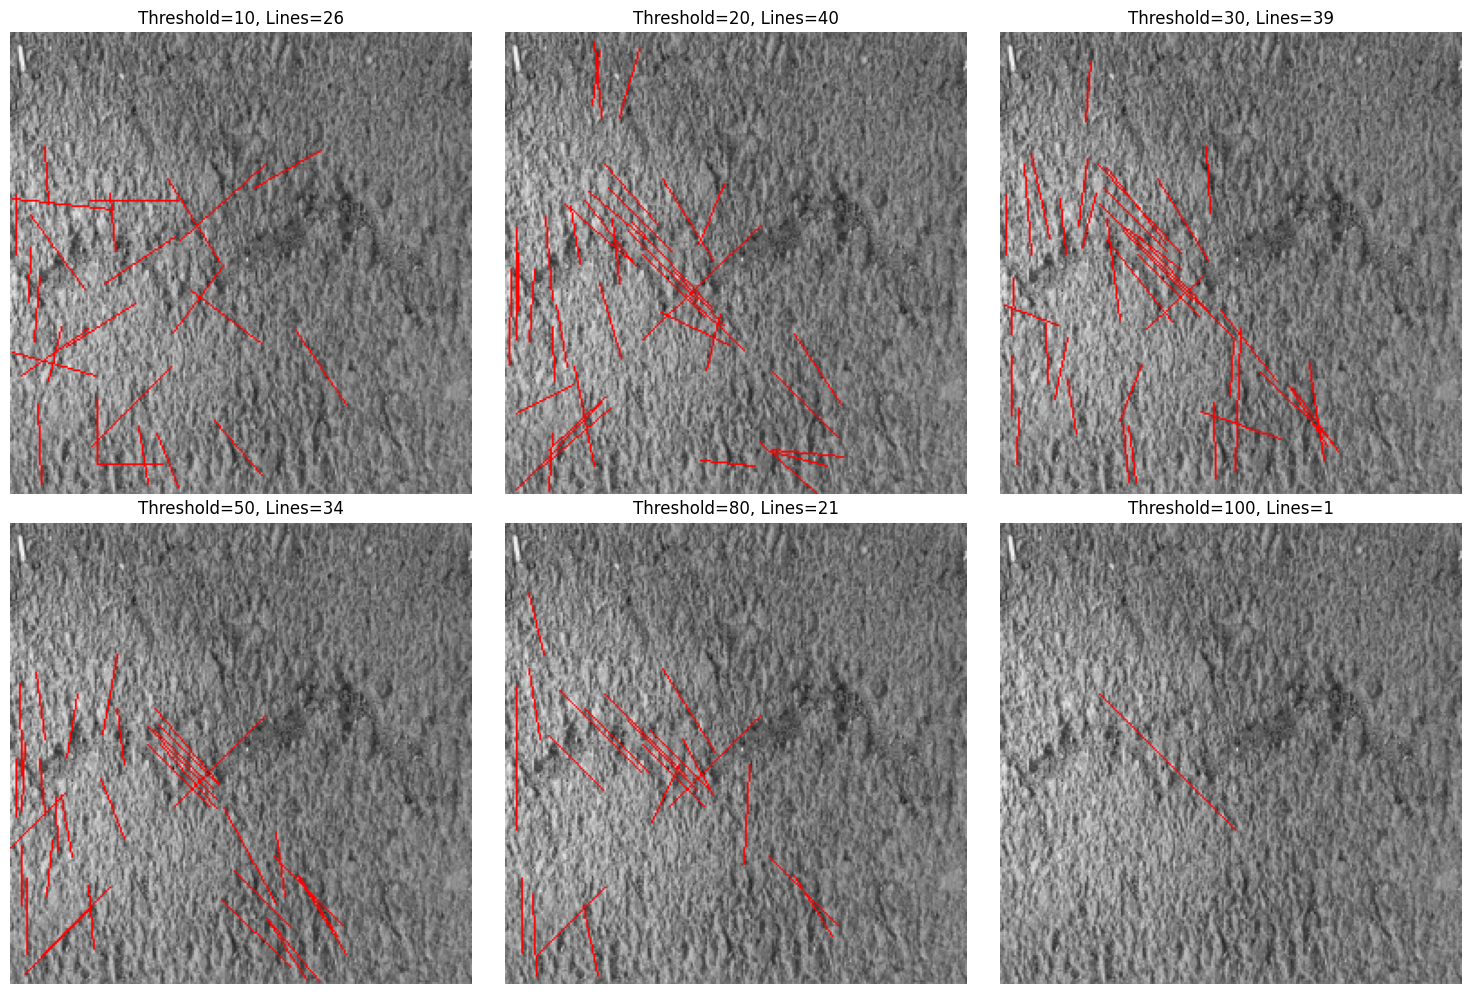

In [21]:
threshold_values = [10, 20, 30, 50, 80, 100]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, threshold in zip(axes.ravel(), threshold_values):

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=threshold,
        minLineLength=30,
        maxLineGap=5
    )

    overlay = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)

    if lines is not None:
        for x1, y1, x2, y2 in lines.reshape(-1, 4):
            cv2.line(
                overlay,
                (x1, y1),
                (x2, y2),
                (0, 0, 255),
                1
            )

    count = 0 if lines is None else len(lines)

    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Threshold={threshold}, Lines={count}")
    ax.axis("off")

plt.tight_layout()
plt.show()

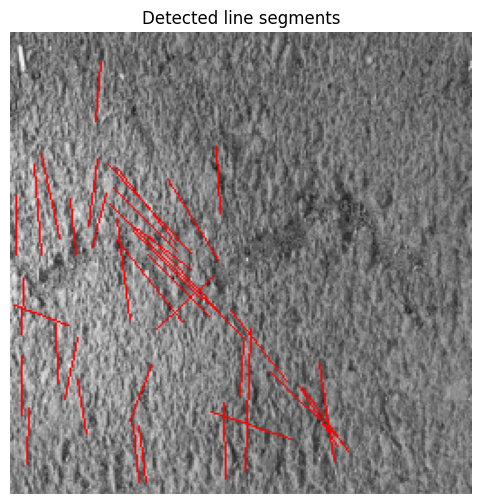

In [22]:
HOUGH_THRESHOLD = 30
HOUGH_MIN_LENGTH = 30
HOUGH_MAX_GAP = 5

# 8.2 Detect line segments
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=HOUGH_THRESHOLD,
    minLineLength=HOUGH_MIN_LENGTH,
    maxLineGap=HOUGH_MAX_GAP
)

overlay = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)
if lines is not None:
    for x1, y1, x2, y2 in lines.reshape(-1, 4):
        cv2.line(overlay, (x1, y1), (x2, y2), (0, 0, 255), 1)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Detected line segments")
plt.axis("off")
plt.show()

In [23]:
if lines is None:
    print("No lines detected")
else:
    segs = lines.reshape(-1, 4)
    dx = segs[:, 2] - segs[:, 0]
    dy = segs[:, 3] - segs[:, 1]

    line_lengths = np.hypot(dx, dy)                      # 8.4
    line_angles = np.degrees(np.arctan2(dy, dx)) % 180   # 8.5  (orientation in [0, 180))

    print("Line count      :", len(segs))                # 8.3
    print("Mean length     :", line_lengths.mean())
    print("Max length      :", line_lengths.max())
    print("Mean angle (deg):", line_angles.mean())
    print("Std angle (deg) :", line_angles.std())

Line count      : 39
Mean length     : 44.66485896522042
Max length      : 106.06601717798213
Mean angle (deg): 72.82098214070093
Std angle (deg) : 26.092403306296386


### Feature Extraction

In [25]:
from skimage.feature import local_binary_pattern

DARK_THRESHOLD = 50
BRIGHT_THRESHOLD = 200
USE_CLAHE = False          # set True to compute all features on the CLAHE image


def preprocess_image(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.resize(image, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    if USE_CLAHE:
        gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)

    blurred = cv2.GaussianBlur(gray, BLUR_KSIZE, 0)
    return gray, blurred


def image_entropy(image):
    counts, _ = np.histogram(image, bins=256, range=(0, 256))
    p = counts / counts.sum()
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


def intensity_features(gray):
    g = gray.astype(np.float64)
    p5, q25, q75, p95 = np.percentile(g, [5, 25, 75, 95])
    flat = g.ravel()

    return {
        "mean_brightness": g.mean(),
        "contrast": g.std(),
        "min_intensity": g.min(),
        "max_intensity": g.max(),
        "intensity_range": g.max() - g.min(),
        "median_intensity": np.median(g),
        "p5": p5, "q25": q25, "q75": q75, "p95": p95,
        "iqr": q75 - q25,
        "skewness": stats.skew(flat),
        "kurtosis": stats.kurtosis(flat),
        "entropy": image_entropy(gray),
        "dark_pixel_ratio": np.mean(g < DARK_THRESHOLD),
        "bright_pixel_ratio": np.mean(g > BRIGHT_THRESHOLD),
    }

def lbp_features(gray):
    P = 8       # Number of neighbouring points
    R = 1       # Radius of neighbourhood

    lbp = local_binary_pattern(
        gray,
        P,
        R,
        method="uniform"
    )

    # Histogram of LBP patterns
    n_bins = P + 2
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_bins + 1),
        range=(0, n_bins)
    )

    # Normalize histogram
    hist = hist.astype(float)
    hist /= hist.sum()

    return {
        f"lbp_{i}": value
        for i, value in enumerate(hist)
    }

def canny_features(blurred):
    lo, hi = get_canny_thresholds(blurred)
    edges = cv2.Canny(blurred, lo, hi)
    count = np.count_nonzero(edges)
    return {"edge_count": count, "edge_density": count / edges.size}, edges


def gradient_features(blurred):
    sx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx ** 2 + sy ** 2)
    return {
        "sobel_x_mean": np.mean(np.abs(sx)), "sobel_x_std": sx.std(),
        "sobel_y_mean": np.mean(np.abs(sy)), "sobel_y_std": sy.std(),
        "grad_mag_mean": mag.mean(), "grad_mag_std": mag.std(),
    }


def hough_features(edges):
    empty = {"hough_line_count": 0, "hough_mean_length": 0.0, "hough_max_length": 0.0,
             "hough_total_length": 0.0, "hough_mean_angle": 0.0, "hough_std_angle": 0.0}

    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=HOUGH_THRESHOLD,
                            minLineLength=HOUGH_MIN_LENGTH, maxLineGap=HOUGH_MAX_GAP)
    if lines is None:
        return empty

    segs = lines.reshape(-1, 4)
    dx = segs[:, 2] - segs[:, 0]
    dy = segs[:, 3] - segs[:, 1]
    lengths = np.hypot(dx, dy)
    angles = np.degrees(np.arctan2(dy, dx)) % 180

    return {"hough_line_count": len(segs), "hough_mean_length": lengths.mean(),
            "hough_max_length": lengths.max(), "hough_total_length": lengths.sum(),
            "hough_mean_angle": angles.mean(), "hough_std_angle": angles.std()}


def extract_image_features(image_path):
    gray, blurred = preprocess_image(image_path)

    features = {}
    features.update(intensity_features(gray))
    features.update(lbp_features(gray))
    canny_feats, edges = canny_features(blurred)
    features.update(canny_feats)
    features.update(gradient_features(blurred))
    features.update(hough_features(edges))

    return features

In [26]:
# Test on the crack and non-crack samples
sample_table = pd.DataFrame({
    "Crack": extract_image_features(crack_path),
    "Non-crack": extract_image_features(noncrack_path),
})
sample_table

,Crack,Non-crack
mean_brightness,122.100815,157.233902
contrast,30.727239,15.108970
min_intensity,23.000000,85.000000
max_intensity,246.000000,240.000000
intensity_range,223.000000,155.000000
median_intensity,120.000000,157.000000
p5,74.000000,133.000000
q25,101.000000,147.000000
q75,141.000000,168.000000
p95,177.000000,182.000000


In [27]:
rows = []
start = time.perf_counter()

for _, r in df.iterrows():
    feats = extract_image_features(r["path"])
    feats["image_name"] = r["image_name"]
    feats["class"] = r["class"]
    feats["label"] = int(r["label"])
    rows.append(feats)

extraction_time = time.perf_counter() - start

features_df = pd.DataFrame(rows)

print("Feature table shape:", features_df.shape)
print(f"Total extraction time : {extraction_time:.2f} s")
print(f"Per image             : {1000 * extraction_time / len(features_df):.2f} ms")

features_df.head()

Feature table shape: (400, 43)
Total extraction time : 15.13 s
Per image             : 37.83 ms


,mean_brightness,contrast,min_intensity,max_intensity,intensity_range,median_intensity,p5,q25,q75,p95,...,grad_mag_std,hough_line_count,hough_mean_length,hough_max_length,hough_total_length,hough_mean_angle,hough_std_angle,image_name,class,label
0,157.233902,15.108970,85.0,240.0,155.0,157.0,133.0,147.0,168.0,182.0,...,18.215515,0,0.0,0.0,0.0,0.0,0.0,IMG_20180705_130729936 resized_448.jpg,NonCracks,0
1,157.721207,16.428223,91.0,244.0,153.0,157.0,133.0,147.0,167.0,185.0,...,17.084283,0,0.0,0.0,0.0,0.0,0.0,IMG_20180705_130731751 resized_448.jpg,NonCracks,0
2,159.768692,14.587853,95.0,243.0,148.0,160.0,136.0,150.0,170.0,183.0,...,17.060298,0,0.0,0.0,0.0,0.0,0.0,IMG_20180705_130732496 resized_448.jpg,NonCracks,0
3,160.017212,14.377647,101.0,242.0,141.0,160.0,137.0,150.0,170.0,183.0,...,17.199837,0,0.0,0.0,0.0,0.0,0.0,IMG_20180705_130732993 resized_448.jpg,NonCracks,0
4,166.112305,19.368171,102.0,253.0,151.0,164.0,139.0,153.0,176.0,204.0,...,17.112934,0,0.0,0.0,0.0,0.0,0.0,IMG_20180705_130733329 resized_448.jpg,NonCracks,0


In [28]:
# Feature groups (used for the ablation later)
_gray, _blur = preprocess_image(crack_path)
INTENSITY_COLS = list(intensity_features(_gray).keys())
_canny, _edges = canny_features(_blur)
CANNY_COLS = list(_canny.keys())
GRADIENT_COLS = list(gradient_features(_blur).keys())
HOUGH_COLS = list(hough_features(_edges).keys())

FEATURE_COLS = INTENSITY_COLS + CANNY_COLS + GRADIENT_COLS + HOUGH_COLS

print({"intensity": len(INTENSITY_COLS), "canny": len(CANNY_COLS),
       "gradient": len(GRADIENT_COLS), "hough": len(HOUGH_COLS), "total": len(FEATURE_COLS)})

print("\nMissing values :", int(features_df[FEATURE_COLS].isna().sum().sum()))
print("Infinite values:", int(np.isinf(features_df[FEATURE_COLS]).sum().sum()))

{'intensity': 16, 'canny': 2, 'gradient': 6, 'hough': 6, 'total': 30}

Missing values : 0
Infinite values: 0


In [29]:
class_means = features_df.groupby("class")[FEATURE_COLS].mean().round(4)
class_means.T

class,Cracks,NonCracks
mean_brightness,144.2482,157.5112
contrast,29.3321,22.3258
min_intensity,29.3000,68.5450
max_intensity,250.6500,249.1600
intensity_range,221.3500,180.6150
median_intensity,144.5350,157.2100
p5,95.4500,121.5838
q25,125.6500,142.5150
q75,163.4450,171.9562
p95,191.8412,194.7400


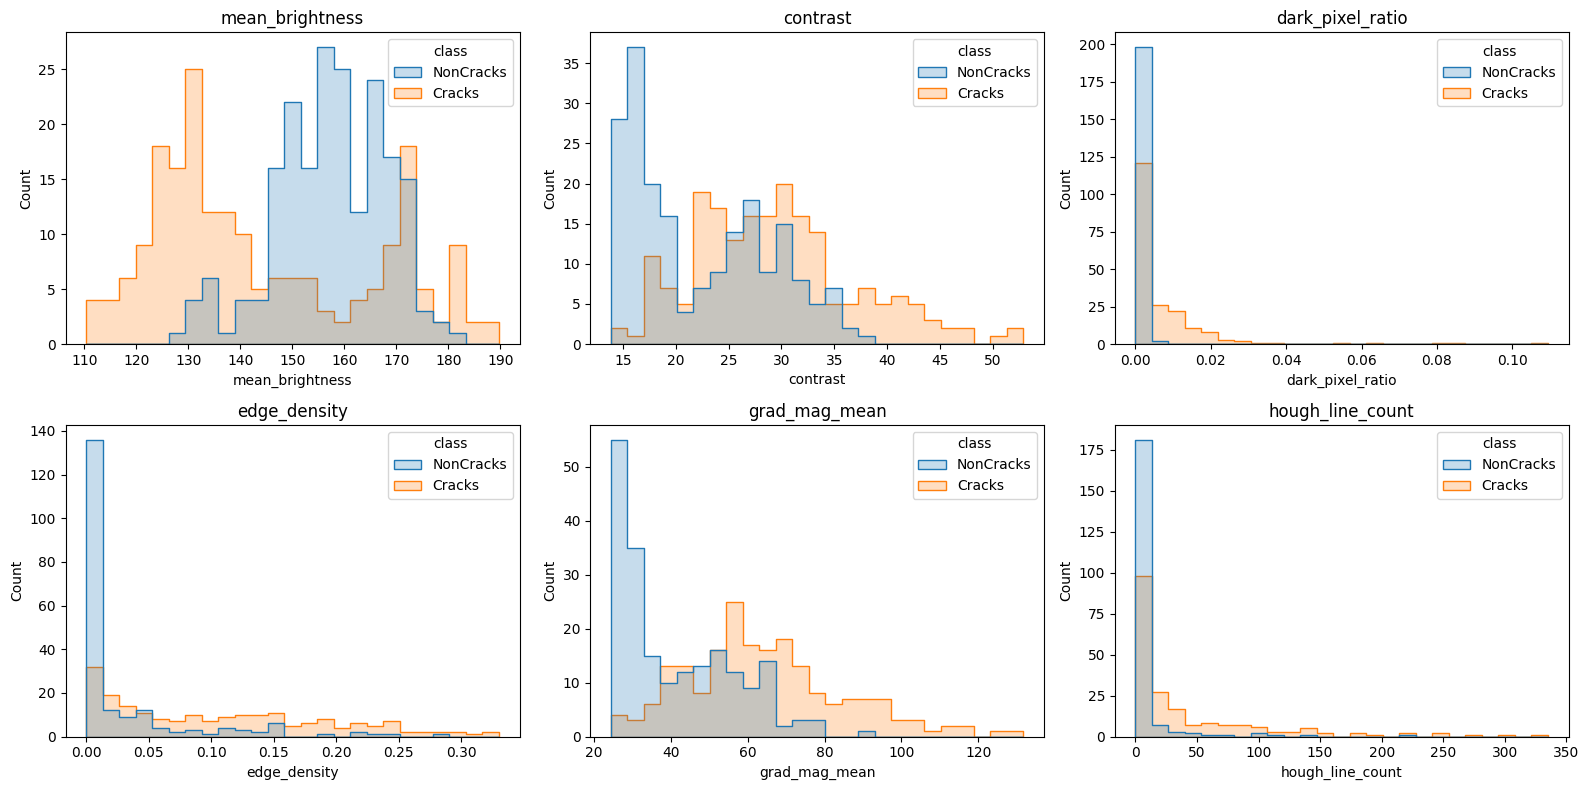

In [30]:
features_to_plot = ["mean_brightness", "contrast", "dark_pixel_ratio",
                    "edge_density", "grad_mag_mean", "hough_line_count"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, feature in zip(axes.ravel(), features_to_plot):
    sns.histplot(data=features_df, x=feature, hue="class", bins=25,
                 element="step", common_norm=False, ax=ax)
    ax.set_title(feature)

plt.tight_layout(); plt.show()

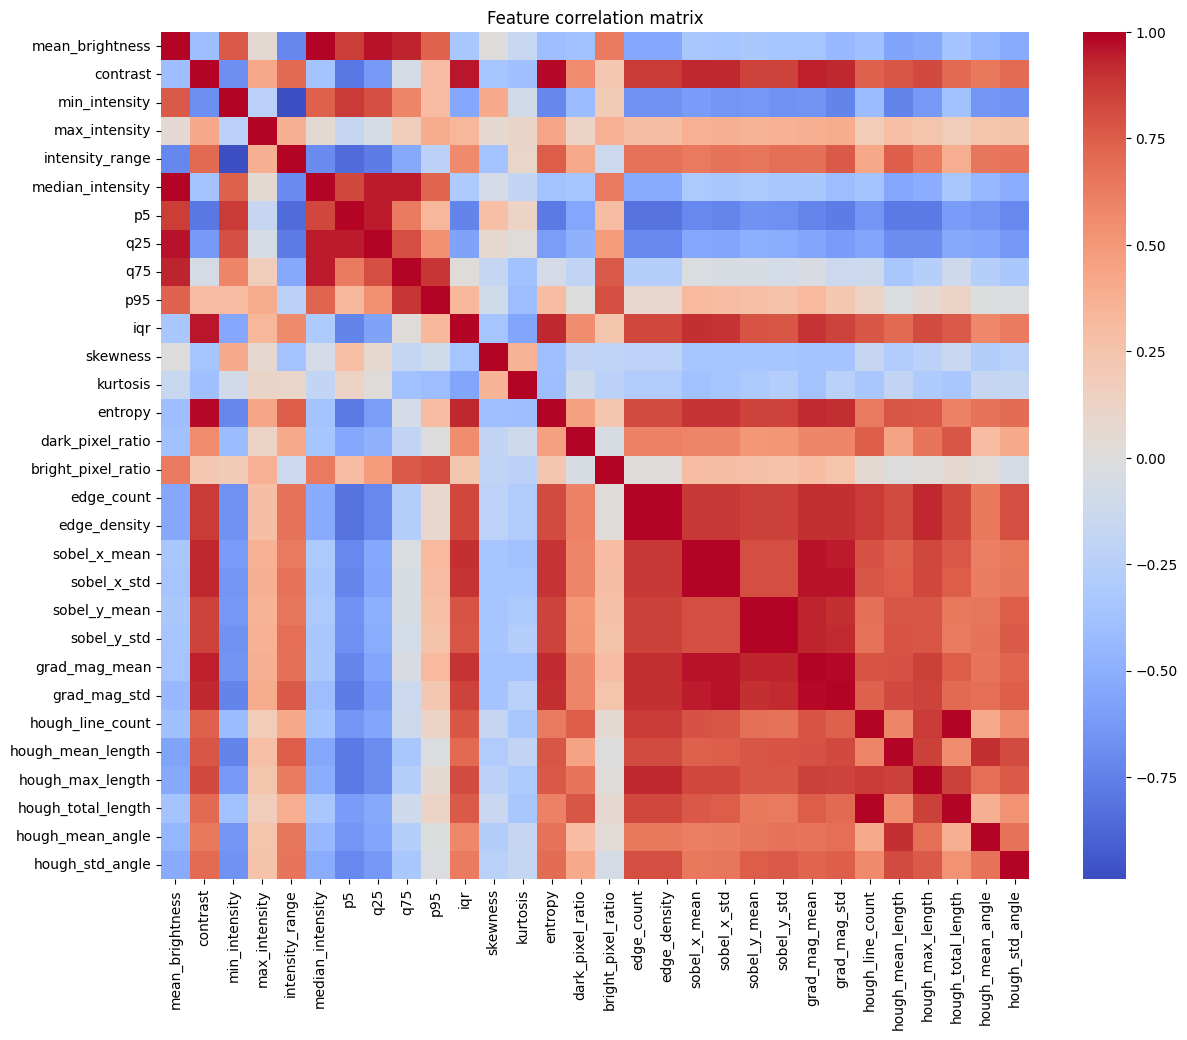

In [31]:
plt.figure(figsize=(14, 11))
sns.heatmap(features_df[FEATURE_COLS].corr(), cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.show()

### Train test split

In [32]:
train_features, test_features = train_test_split(
    features_df,
    test_size=0.20,
    stratify=features_df["label"],
    random_state=RANDOM_STATE
)

train_features = train_features.reset_index(drop=True)
test_features = test_features.reset_index(drop=True)

X_train, y_train = train_features[FEATURE_COLS], train_features["label"]
X_test, y_test = test_features[FEATURE_COLS], test_features["label"]

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nTrain label counts:\n", y_train.value_counts())
print("\nTest label counts:\n", y_test.value_counts())

train_features.to_csv("train_features.csv", index=False)
test_features.to_csv("test_features.csv", index=False)
print("\nSaved train_features.csv and test_features.csv")

Train: (320, 30) | Test: (80, 30)

Train label counts:
 label
1    160
0    160
Name: count, dtype: int64

Test label counts:
 label
0    40
1    40
Name: count, dtype: int64

Saved train_features.csv and test_features.csv


In [37]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
fitted_models = {}
predictions = {}
conf_matrices = {}


def train_and_evaluate(name, estimator, param_grid=None):
    # 1) tuning (training set only)
    tuning_time, best_params = 0.0, {}

    if param_grid:
        search = GridSearchCV(estimator, param_grid, cv=cv5, scoring="f1", n_jobs=-1)
        t0 = time.perf_counter()
        search.fit(X_train, y_train)
        tuning_time = time.perf_counter() - t0
        best_params = search.best_params_
        cv_f1 = search.best_score_
        estimator = clone(search.best_estimator_)
    else:
        cv_f1 = cross_val_score(estimator, X_train, y_train, cv=cv5, scoring="f1").mean()

    # 2) final training time (chosen model, full training set)
    model = clone(estimator)
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    training_time = time.perf_counter() - t0

    # 3) prediction time
    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    prediction_time = time.perf_counter() - t0

    # 4) metrics (Crack = 1 is the positive class)
    cm = confusion_matrix(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "CV F1 (train)": cv_f1,
        "Tuning time (s)": tuning_time,
        "Training time (s)": training_time,
        "Prediction time (s)": prediction_time,
        "Prediction time/image (ms)": 1000 * prediction_time / len(X_test),
        "Best params": best_params,
    })
    fitted_models[name] = model
    predictions[name] = y_pred
    conf_matrices[name] = cm

    print(f"{name}: best params = {best_params}")
    print(classification_report(y_test, y_pred, target_names=["Non-Crack", "Crack"], zero_division=0))

    ConfusionMatrixDisplay(cm, display_labels=["Non-Crack", "Crack"]).plot(cmap="Blues", colorbar=False)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

### ML models

Logistic Regression: best params = {'model__C': 10}
              precision    recall  f1-score   support

   Non-Crack       0.93      0.93      0.93        40
       Crack       0.93      0.93      0.93        40

    accuracy                           0.93        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.93      0.93      0.93        80



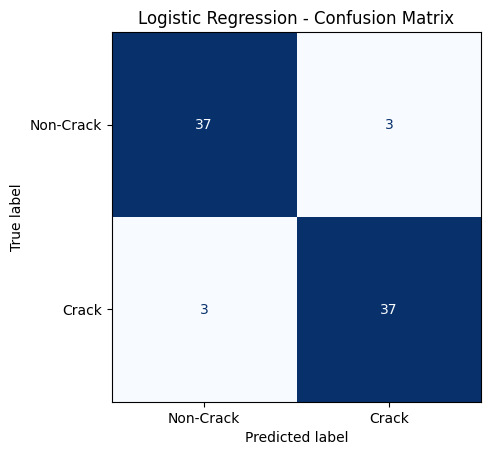

In [39]:
train_and_evaluate(
    "Logistic Regression",
    Pipeline([("scaler", StandardScaler()),
              ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
    {"model__C": [0.01, 0.1, 1, 10, 100]}
)

SVM: best params = {'model__C': 10, 'model__gamma': 'scale'}
              precision    recall  f1-score   support

   Non-Crack       0.95      0.93      0.94        40
       Crack       0.93      0.95      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



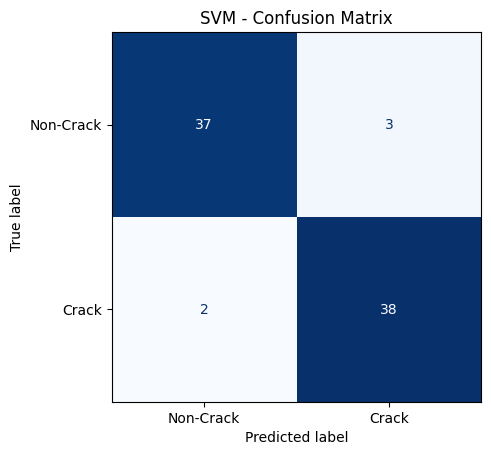

In [40]:
train_and_evaluate(
    "SVM",
    Pipeline([("scaler", StandardScaler()),
              ("model", SVC(kernel="rbf"))]),
    {"model__C": [0.1, 1, 10, 100],
     "model__gamma": ["scale", 0.01, 0.1]}
)

KNN: best params = {'model__n_neighbors': 3, 'model__weights': 'distance'}
              precision    recall  f1-score   support

   Non-Crack       0.93      0.93      0.93        40
       Crack       0.93      0.93      0.93        40

    accuracy                           0.93        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.93      0.93      0.93        80



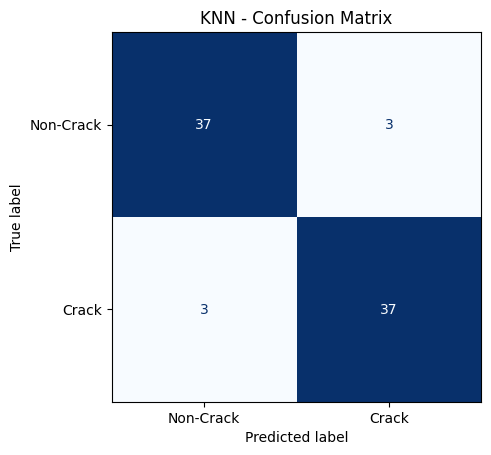

In [41]:
train_and_evaluate(
    "KNN",
    Pipeline([("scaler", StandardScaler()),
              ("model", KNeighborsClassifier())]),
    {"model__n_neighbors": [3, 5, 7, 9, 11, 15],
     "model__weights": ["uniform", "distance"]}
)

Random Forest: best params = {'max_depth': None, 'min_samples_leaf': 1}
              precision    recall  f1-score   support

   Non-Crack       0.93      0.95      0.94        40
       Crack       0.95      0.93      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



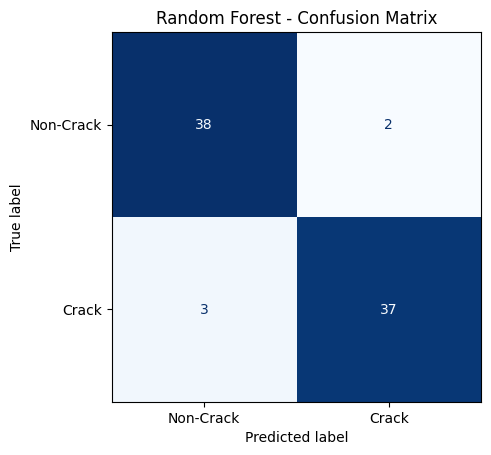

In [42]:
train_and_evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    {"max_depth": [None, 5, 10],
     "min_samples_leaf": [1, 2, 4]}
)

In [43]:
results_df = (pd.DataFrame(results)
              .sort_values("F1-score", ascending=False)
              .reset_index(drop=True))

results_df.drop(columns=["Best params"]).round(4)

,Model,Accuracy,Precision,Recall,F1-score,CV F1 (train),Tuning time (s),Training time (s),Prediction time (s),Prediction time/image (ms)
0,SVM,0.9375,0.9268,0.950,0.9383,0.9841,0.2669,0.0073,0.0026,0.0327
1,Random Forest,0.9375,0.9487,0.925,0.9367,0.9633,4.2696,0.5786,0.0221,0.2758
2,Logistic Regression,0.9250,0.9250,0.925,0.9250,0.9721,12.8556,0.0226,0.0024,0.0305
3,KNN,0.9250,0.9250,0.925,0.9250,0.9492,0.6787,0.0052,0.2606,3.2580


In [45]:
# False positives vs false negatives for each model
for name, cm in conf_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    print(f"{name:24s} TN={tn:3d} FP={fp:3d} FN={fn:3d} TP={tp:3d}")

Logistic Regression      TN= 37 FP=  3 FN=  3 TP= 37
SVM                      TN= 37 FP=  3 FN=  2 TP= 38
KNN                      TN= 37 FP=  3 FN=  3 TP= 37
Random Forest            TN= 38 FP=  2 FN=  3 TP= 37


### Which features matter?

In [46]:
ablation_sets = {
    "Intensity only": INTENSITY_COLS,
    "Canny only": CANNY_COLS,
    "Intensity + Canny": INTENSITY_COLS + CANNY_COLS,
    "+ Gradient": INTENSITY_COLS + CANNY_COLS + GRADIENT_COLS,
    "+ Hough (all features)": FEATURE_COLS,
}

ablation_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC())
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
}
rows = []
for set_name, cols in ablation_sets.items():
    for model_name, model in ablation_models.items():
        cv_f1 = cross_val_score(model, X_train[cols], y_train, cv=cv5, scoring="f1").mean()
        m = clone(model).fit(X_train[cols], y_train)
        test_f1 = f1_score(y_test, m.predict(X_test[cols]))
        rows.append({"Feature set": set_name, "Model": model_name,
                     "n_features": len(cols), "CV F1 (train)": cv_f1, "Test F1": test_f1})

ablation_df = pd.DataFrame(rows)
ablation_df.round(4)

,Feature set,Model,n_features,CV F1 (train),Test F1
0,Intensity only,Logistic Regression,16,0.9453,0.9250
1,Intensity only,SVM,16,0.9617,0.9500
2,Intensity only,KNN,16,0.9594,0.9367
3,Intensity only,Random Forest,16,0.9543,0.9500
4,Canny only,Logistic Regression,2,0.6833,0.6667
5,Canny only,SVM,2,0.7547,0.7013
6,Canny only,KNN,2,0.7713,0.7416
7,Canny only,Random Forest,2,0.7312,0.6154
8,Intensity + Canny,Logistic Regression,18,0.9400,0.9231
9,Intensity + Canny,SVM,18,0.9655,0.9367


In [47]:
def capture_group(name):
    m = re.search(r"IMG_(\d{8})_(\d{2})(\d{2})(\d{2})", name)
    if m:
        date, hh, mm, _ = m.groups()
        return f"ts_{date}_{hh}_{int(mm) // 5}"

    m = re.search(r"IMG_(\d+)", name)
    if m:
        return f"n_{int(m.group(1)) // 10}"

    return name


features_df["capture_group"] = features_df["image_name"].apply(capture_group)

print("Number of groups:", features_df["capture_group"].nunique())
print("Images per group (describe):")
print(features_df.groupby("capture_group").size().describe())

Number of groups: 43
Images per group (describe):
count    43.000000
mean      9.302326
std       7.676603
min       1.000000
25%       5.000000
50%      10.000000
75%      10.000000
max      51.000000
dtype: float64


In [48]:
X_all = features_df[FEATURE_COLS]
y_all = features_df["label"]
groups = features_df["capture_group"]

plain_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
group_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

check_models = {
    "Logistic Regression": ablation_models["Logistic Regression"],
    "SVM": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf"))]),
    "Random Forest": ablation_models["Random Forest"],
}

rows = []
for name, model in check_models.items():
    plain = cross_val_score(model, X_all, y_all, cv=plain_cv, scoring="f1")
    grouped = cross_val_score(model, X_all, y_all, cv=group_cv, groups=groups, scoring="f1")
    rows.append({"Model": name,
                 "F1 (random folds)": plain.mean(),
                 "F1 (group folds)": grouped.mean(),
                 "Difference": plain.mean() - grouped.mean()})

pd.DataFrame(rows).round(4)

,Model,F1 (random folds),F1 (group folds),Difference
0,Logistic Regression,0.9543,0.8878,0.0665
1,SVM,0.9478,0.8934,0.0545
2,Random Forest,0.9555,0.9233,0.0323


Additional structural features such as Sobel gradients and Hough-based line information were explored to capture information that simple edge density cannot represent. This is useful because edge density measures only the amount of edge structure, while cracks may also differ in gradient strength, connectivity, orientation, and line-like geometry.

PART B including Part C

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

In [52]:
email_df = pd.read_csv("data/emails.csv")

print("Shape:", email_df.shape)
display(email_df.head())

print("\nClass distribution:")
print(email_df["Prediction"].value_counts())

print("\nClass proportions:")
print(email_df["Prediction"].value_counts(normalize=True))

Shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0



Class distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Class proportions:
Prediction
0    0.709977
1    0.290023
Name: proportion, dtype: float64


In [59]:
target_counts = email_df["Prediction"].value_counts().sort_index()

print("Prediction distribution:")
print(target_counts)

print("\nPrediction percentage:")
print(
    email_df["Prediction"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Prediction distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Prediction percentage:
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64


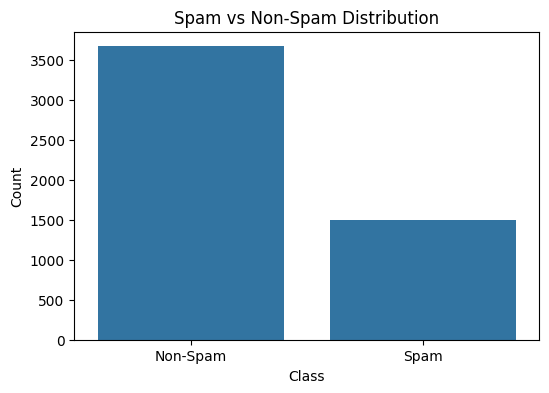

In [53]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=email_df,
    x="Prediction"
)

plt.xticks(
    [0, 1],
    ["Non-Spam", "Spam"]
)

plt.title("Spam vs Non-Spam Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [54]:
X_count = email_df.drop(
    columns=["Email No.", "Prediction"]
)

y = email_df["Prediction"]

print("Count feature matrix shape:", X_count.shape)
print("Number of count features:", X_count.shape[1])

Count feature matrix shape: (5172, 3000)
Number of count features: 3000


In [55]:
zero_fraction = (
    X_count.eq(0).sum().sum()
    / X_count.size
)

print(
    f"Sparsity: {zero_fraction * 100:.2f}% zeros"
)

Sparsity: 94.37% zeros


In [56]:
X_train_count, X_test_count, y_train, y_test = train_test_split(
    X_count,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train_count.shape)
print("Test shape:", X_test_count.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training shape: (4137, 3000)
Test shape: (1035, 3000)

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Test class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


In [60]:
print("Unique labels:", sorted(email_df["Prediction"].unique()))

print("\nNumber of columns:", len(email_df.columns))

print("\nFirst 20 columns:")
print(email_df.columns[:20].tolist())

print("\nLast 10 columns:")
print(email_df.columns[-10:].tolist())

Unique labels: [np.int64(0), np.int64(1)]

Number of columns: 3002

First 20 columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have']

Last 10 columns:
['connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military', 'allowing', 'ff', 'dry', 'Prediction']


In [61]:
X_text = email_df.drop(
    columns=["Prediction", "Email No."],
    errors="ignore"
)

y_text = email_df["Prediction"]

print("X shape:", X_text.shape)
print("y shape:", y_text.shape)

X shape: (5172, 3000)
y shape: (5172,)


In [ ]:
X_train

,mean_brightness,contrast,min_intensity,max_intensity,intensity_range,median_intensity,p5,q25,q75,p95,...,sobel_y_mean,sobel_y_std,grad_mag_mean,grad_mag_std,hough_line_count,hough_mean_length,hough_max_length,hough_total_length,hough_mean_angle,hough_std_angle
0,166.005600,31.917580,32.0,253.0,221.0,164.0,118.0,146.0,186.0,222.0,...,39.667206,52.198520,71.463089,46.415345,8,50.289852,79.309520,402.318820,95.247182,30.226507
1,139.835541,45.023313,20.0,253.0,233.0,142.0,63.0,107.0,174.0,211.0,...,47.894745,61.597725,100.672449,59.444173,186,52.492984,189.504617,9763.694972,87.015570,48.064702
2,168.910812,19.221818,84.0,253.0,169.0,166.0,143.0,156.0,179.0,206.0,...,22.834778,29.663097,36.980519,22.419926,0,0.000000,0.000000,0.000000,0.000000,0.000000
3,150.922897,27.481138,48.0,253.0,205.0,151.0,105.0,132.0,170.0,195.0,...,25.457214,32.710108,47.309594,27.545744,0,0.000000,0.000000,0.000000,0.000000,0.000000
4,146.696686,28.492756,25.0,251.0,226.0,150.0,94.0,130.0,165.0,189.0,...,27.367767,36.296816,44.674747,28.947182,0,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,165.179504,18.883592,82.0,253.0,171.0,165.0,135.0,153.0,176.0,197.0,...,22.951523,29.752677,36.739379,21.923839,0,0.000000,0.000000,0.000000,0.000000,0.000000
316,134.386459,30.224324,4.0,253.0,249.0,134.0,84.0,117.0,152.0,185.0,...,42.749710,55.469790,70.210554,41.849114,33,42.305732,57.982756,1396.089163,110.120334,40.087926
317,159.870834,15.671613,92.0,249.0,157.0,160.0,135.0,150.0,170.0,186.0,...,20.787827,26.658306,28.806764,17.081111,0,0.000000,0.000000,0.000000,0.000000,0.000000
318,154.748093,39.878395,39.0,254.0,215.0,158.0,84.0,126.0,186.0,214.0,...,47.491501,60.788405,102.050716,58.888481,103,50.232943,125.865007,5173.993168,84.963164,48.023725


In [65]:
from sklearn.svm import LinearSVC
models = {
    "Multinomial NB": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        random_state=42
    )
}

In [67]:
results = []
predictions = {}

for name, model in models.items():

    # Training time
    start = time.perf_counter()

    model.fit(
        X_train_count,
        y_train
    )

    training_time = (
        time.perf_counter() - start
    )

    # Prediction time
    start = time.perf_counter()

    y_pred = model.predict(
        X_test_count
    )

    prediction_time = (
        time.perf_counter() - start
    )

    # Metrics
    results.append({
        "Model": name,
        "Features": X_train_count.shape[1],

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Training Time (s)":
            training_time,

        "Prediction Time (s)":
            prediction_time,

        "Prediction Time / Email (ms)":
            1000 * prediction_time / len(y_test)
    })

    predictions[name] = y_pred

In [68]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

display(results_df.round(4))

,Model,Features,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s),Prediction Time / Email (ms)
0,Logistic Regression,3000,0.9826,0.9578,0.9833,0.9704,8.3574,0.0446,0.0430
1,Linear SVM,3000,0.9797,0.9604,0.9700,0.9652,2.8700,0.0469,0.0453
2,Multinomial NB,3000,0.9420,0.8681,0.9433,0.9042,0.0665,0.0482,0.0466


In [69]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

k_values = [300, 500, 1000, 1500, 2000]

feature_selection_results = []

for k in k_values:

    selector = SelectKBest(
        score_func=chi2,
        k=k
    )

    X_train_k = selector.fit_transform(
        X_train_count,
        y_train
    )

    # Use the same model for fair comparison
    model = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train_k,
        y_train,
        cv=5,
        scoring="f1"
    )

    feature_selection_results.append({
        "Features": k,
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 Std": cv_scores.std()
    })

feature_selection_df = pd.DataFrame(
    feature_selection_results
)

feature_selection_df

,Features,CV F1 Mean,CV F1 Std
0,300,0.937958,0.007198
1,500,0.933944,0.005963
2,1000,0.942377,0.005765
3,1500,0.948264,0.005407
4,2000,0.950251,0.011394


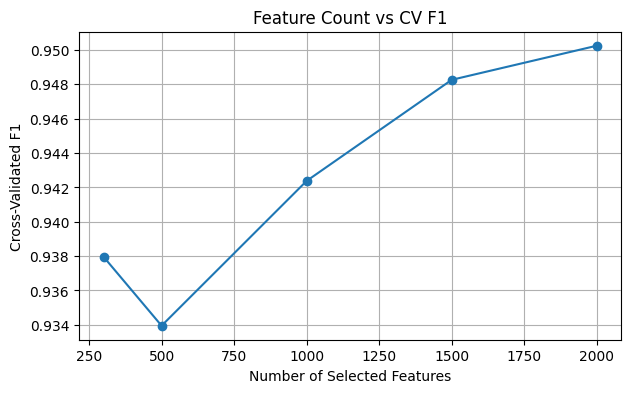

In [70]:
plt.figure(figsize=(7, 4))

plt.plot(
    feature_selection_df["Features"],
    feature_selection_df["CV F1 Mean"],
    marker="o"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated F1")
plt.title("Feature Count vs CV F1")

plt.grid(True)
plt.show()

The email dataset was already available in a processed Bag-of-Words form, with each email represented by a large set of word-count features. To reduce dimensionality and potentially limit overfitting, chi-square based feature selection was applied using different numbers of selected features.
The cross-validation results showed that very aggressive reduction did not improve performance. Using 300 and 500 features gave lower mean F1 scores of approximately 0.938 and 0.934, respectively. Performance improved as more informative features were retained, reaching approximately 0.942 with 1000 features, 0.948 with 1500 features, and the highest observed CV F1 of approximately 0.950 with 2000 selected features.
lower-dimensional representations are computationally simpler, but excessive feature reduction can reduce classification quality. Around 1500–2000 features provided the best balance between dimensionality reduction and classification performance.